# 6. Can Anand's analyst audit every decision tonight and rebuild the clean file from the log alone?

Week 1, Wednesday, chapter 6 of 6. Chapter 5 proved Q1 with a bridge, a walk from one figure to the other in moves, each move one cause
with its rupees: copies of corporate orders, Rs 19,67,560, and copies of consumer orders, Rs 30,650,
take the dashboard's Rs 2,09,98,210 down to Rs 1,90,00,000, the books, Finance's own record of Q1.
It also found that Tuesday's finding survives, smaller: orders per customer in Retail-Plus, Kalpa's
paid membership tier, fall 35.0 percent on clean data against the 49 Tuesday reported. The pass is
the chain of steps that cleans the raw export from the ERP, the enterprise resource planning system
Finance books orders in, and this chapter turns what it did into logs a stranger can audit and
replay.

> **The client asks.** "Your dashboard says Q1 was Rs 2.1 crore. Our books say 1.9. Until your
> numbers match ours, Finance will not act on a drop measured from an ERP export. Send me a
> reconciliation."
>
> Anand Iyer, finance controller, Kalpa Retail

**Who needs the answer.** Anand Iyer's analyst, who ties out every figure by matching it to the books line by line, checks the
logs tonight: the files that record every row the pass set aside and every decision it made. An
auditor may ask next quarter why any row went. A log she cannot follow costs a week of questions,
and one that ties in rows and misses in rupees costs the team her trust in everything else it sends.

**The questions on the way.**

1. What could the analyst receive, and how long would each take her to check?
2. Which decision moved the most rupees?
3. Do the logs on disk hold what the notebook holds?
4. If the rows reconcile, is the log right?
5. Why were 14 Q1 rows set aside, and how do we know nothing else went?
6. Can the clean file be rebuilt from the raw export and the log alone?

**The need.** The metric is a pair of control totals, a count and a sum computed at both ends of a
transfer and compared: rows and rupees, tying from the export to the clean file to the books, with
every row that left traceable to a rule.

**Who else faces it.** At Patisserie Valerie, a UK cafe chain, the administrators put the accounting hole at GBP 94 million in March 2019 (BBC News, 15 March 2019), and in September 2021 the Financial Reporting Council fined its former auditor GBP 4 million, reduced to GBP 2.34 million, for missing red flags in three years of audits (FRC, 27 September 2021; both checked 30 Sep 2026). Anand's auditor may ask the same of Kalpa's log next quarter: whether every row that left can be traced to a reason.

For more depth on the business behind these numbers, the retail dossier,
`content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, covers how the business makes money
in section 3, who decides what in section 4, and in section 5 the revenue tree, which writes revenue as
customers x orders per customer x revenue per order.

**Setup.** The cell loads the shared helper `kit` and the whole pass as one function, `clean_pass()`:
the identity rule keeps one row per `order_id`, the copy whose amount converts, and writes every
other row to the set-aside log with its reason; conversion sends any amount that fails to the
rejects log; and the flags log holds the two records kept with a question on them, the one order
with no status and the largest Q2 order, a bulk order from an account in the Business segment,
Kalpa's sales to companies, where every order runs to lakhs.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import csv, json, math
from collections import Counter
from datetime import date

DATA = kit.data_dir()
ORDERS_CSV = DATA / "C2_W01_D03_orders_STUDENT.csv"
BOOKS_Q1 = 19000000        # Anand's Q1 to the rupee, which his analyst sends on request

def read_orders(path=ORDERS_CSV):
    """Every row of an export as a dictionary of text, with the file line it came from."""
    with open(path, newline="", encoding="utf-8") as f:
        return [dict(row, line=n) for n, row in enumerate(csv.DictReader(f), start=2)]

def convert(value):
    """A whole number of rupees, or None with the reason, so a failure is counted, never hidden."""
    try:
        return int(value), ""
    except (TypeError, ValueError):
        return None, "amount does not convert to a whole number"

def Q(rows, quarter):
    """Rupees in a quarter over the amounts that convert."""
    return sum(convert(r["amount"])[0] or 0 for r in rows if r["quarter"] == quarter)

FIELDS = ["order_id", "customer_id", "segment", "channel", "city", "order_date", "amount",
          "status", "quarter", "discount"]
NUMERIC = {"amount", "discount"}

def profile(rows, fields=FIELDS):
    """Per field: present, convertible where the field is a number, and distinct."""
    out = {}
    for f in fields:
        present = [r.get(f, "") for r in rows if r.get(f, "") not in ("", None)]
        ok = [v for v in present if convert(v)[0] is not None] if f in NUMERIC else present
        out[f] = {"present": len(present), "convertible": len(ok), "distinct": len(set(present))}
    return out

def identity_rule(rows, key="order_id"):
    """One row per order: the first copy whose amount converts stays, and every other row is logged."""
    groups = {}
    for r in rows:
        groups.setdefault(r[key], []).append(r)
    kept, log = [], []
    for k, rs in groups.items():
        valid = [r for r in rs if convert(r["amount"])[0] is not None]
        keep = (valid or rs)[0]
        kept.append(keep)
        for r in rs:
            if r is keep:
                continue
            differs = [f for f in r if f != "line" and r[f] != keep[f]]
            reason = ("copy whose amount does not convert; its twin carries the value"
                      if convert(r["amount"])[0] is None else "second copy of the order")
            if differs and "amount" not in differs:
                reason += "; differs on " + ", ".join(differs)
            log.append({"line": r["line"], "order_id": k, "quarter": r["quarter"], "segment": r["segment"],
                        "amount": r["amount"], "rule": key, "reason": reason, "kept_line": keep["line"]})
    return kept, log

def clean_pass(raw):
    """The day's pass: the identity rule, then conversion with a rejects log, then flags."""
    kept, set_aside = identity_rule(raw)
    clean, rejects, flags = [], [], []
    for r in kept:
        value, reason = convert(r["amount"])
        if value is None:
            rejects.append({"line": r["line"], "order_id": r["order_id"], "field": "amount",
                            "value": r["amount"], "reason": reason})
            continue
        if not r["status"]:
            flags.append({"line": r["line"], "order_id": r["order_id"], "field": "status",
                          "decision": "keep and flag", "why": "booked revenue; its fate is unknown"})
        clean.append(dict(r, amount=value))
    q2 = [r for r in clean if r["quarter"] == "Q2"]
    top = max(q2, key=lambda r: r["amount"])
    flags.append({"line": top["line"], "order_id": top["order_id"], "field": "amount",
                  "decision": "keep and flag", "why": "the largest Q2 order, a real Business account; shown both ways"})
    return clean, set_aside, rejects, flags

def per_customer(rows, quarter, segment):
    rs = [r for r in rows if r["quarter"] == quarter and r["segment"] == segment]
    return len(rs) / len({r["customer_id"] for r in rs})

import tempfile, pathlib
raw = read_orders()
clean, set_aside, rejects, flags = clean_pass(raw)
print(len(clean), "orders;", len(set_aside), "set aside;", len(rejects), "rejected;", len(flags), "flagged")

186 orders; 15 set aside; 0 rejected; 2 flagged


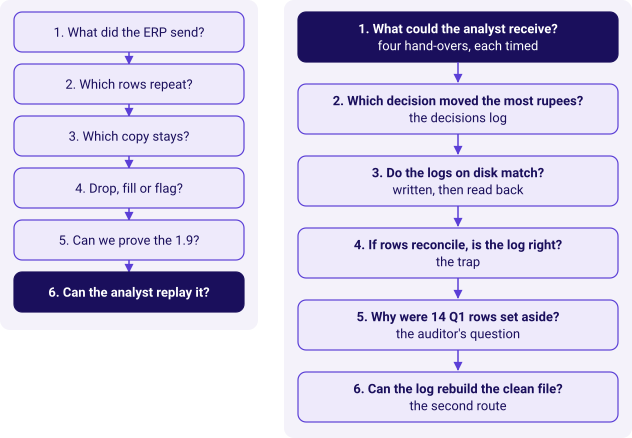

In [2]:
kit.side_by_side(
    kit.ladder(["What did the ERP send?", "Which rows repeat?", "Which copy stays?", "Drop, fill or flag?", "Can we prove the 1.9?", "Can the analyst replay it?"], lit=5, show=False),
    kit.vflow(["1. What could the analyst receive?\nfour hand-overs, each timed", "2. Which decision moved the most rupees?\nthe decisions log", "3. Do the logs on disk match?\nwritten, then read back", "4. If rows reconcile, is the log right?\nthe trap", "5. Why were 14 Q1 rows set aside?\nthe auditor's question", "6. Can the log rebuild the clean file?\nthe second route"], lit=0, show=False),
)

## 1. What could the analyst receive, and how long would each take her to check?

| Option | What the analyst receives | What the analyst can do with it |
|---|---|---|
| a) The clean file alone | 186 rows, read against the 201 raw | diff them by hand, with no reasons |
| b) The clean file and a count | 186 rows and "15 set aside" | tie the rows, and nothing else |
| c) Row logs, a decisions log and control totals | 15 set-aside rows with reasons, the flags, five decisions, rows and rupees | tie both totals and replay the pass |
| d) A full diff of the two files | 201 lines marked kept or gone | see what went, and never why |

option,lines to read,ties rows,ties rupees,can be replayed
a) clean file read against raw,387,by hand,no,no
b) file and a count,1,yes,no,no
c) logs and control totals,24,yes,yes,yes
d) a full diff,201,yes,by hand,no


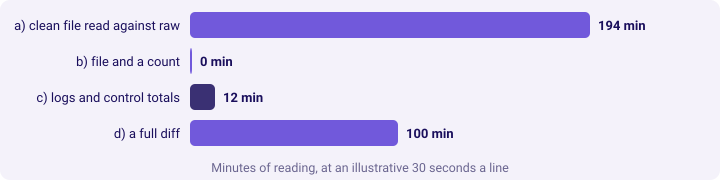

In [3]:
per_line = 30    # seconds an analyst spends on one line of a log or a diff: an illustrative assumption
sizing = [("a) clean file read against raw", 201 + 186, "by hand", "no", "no"),
          ("b) file and a count", 1, "yes", "no", "no"),
          ("c) logs and control totals", len(set_aside) + len(rejects) + len(flags) + 5 + 2, "yes", "yes", "yes"),
          ("d) a full diff", 201, "yes", "by hand", "no")]
kit.table(["option", "lines to read", "ties rows", "ties rupees", "can be replayed"],
          [(n, l, a, b, c) for n, l, a, b, c in sizing], caption="Each hand-over sized for the analyst")
kit.bars([(n, l * per_line / 60) for n, l, *_ in sizing], fmt=lambda v: f"{v:.0f} min",
         lit=(2,), title="Minutes of reading, at an illustrative 30 seconds a line")

**The best-fit call.** Option c is 24 lines that tie both totals, and the analyst can re-run the
pass from them. Option b is the fastest read and proves the least; a and d cost over an hour and
still do not say why. **What would switch it.** An analyst who must re-derive every
row independently, as an external auditor sometimes must; then d goes alongside c.

## 2. Which decision moved the most rupees?

The decisions log gives each rule one line, with the rows it touched and the Q1 rupees it moved.

**Predict before you run.** Which decision moves the most rupees in Q1? a) the identity rule;
b) the missing status; c) the bulk order; d) the missing discount.

decision,rows it touched,Q1 rupees it moved
"one row per order_id, the copy that validates stays",15,"-Rs 19,98,210"
"an amount that does not convert is rejected, never zeroed",0,Rs 0
a missing status is kept and flagged,1,Rs 0
"a missing discount stays unknown, never zero",55,Rs 0
the largest Q2 order is kept and flagged,1,Rs 0


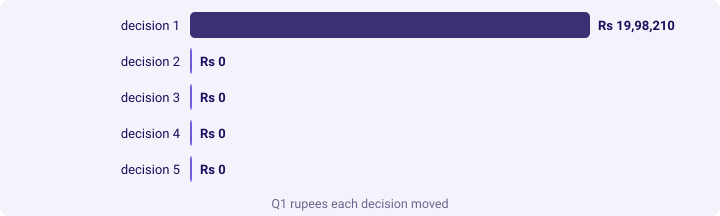

In [4]:
q1_aside = sum(convert(e["amount"])[0] or 0 for e in set_aside if e["quarter"] == "Q1")
decisions = [
    {"decision": "one row per order_id, the copy that validates stays", "rows": len(set_aside), "q1_rupees": -q1_aside},
    {"decision": "an amount that does not convert is rejected, never zeroed", "rows": len(rejects), "q1_rupees": 0},
    {"decision": "a missing status is kept and flagged", "rows": sum(1 for f in flags if f["field"] == "status"), "q1_rupees": 0},
    {"decision": "a missing discount stays unknown, never zero", "rows": sum(1 for r in clean if r["discount"] == ""), "q1_rupees": 0},
    {"decision": "the largest Q2 order is kept and flagged", "rows": 1, "q1_rupees": 0},
]
kit.table(["decision", "rows it touched", "Q1 rupees it moved"],
          [(d["decision"], d["rows"], kit.rupees(d["q1_rupees"])) for d in decisions], caption="The decisions log")
kit.bars([(f"decision {i + 1}", abs(d["q1_rupees"])) for i, d in enumerate(decisions)], fmt=kit.rupees, lit=(0,),
         title="Q1 rupees each decision moved")
kit.check("the decisions' rupees add to the whole gap", Q(raw, "Q1") + sum(d["q1_rupees"] for d in decisions) == BOOKS_Q1)

**What happened.** The answer is a. The identity rule moves all Rs 19,98,210; the other four decisions
move no Q1 rupees and each still gets a line, because an analyst who finds an unlogged decision
stops trusting the logged ones.

## 3. Do the logs on disk hold what the notebook holds?

The analyst reads the logs as files, so the notebook writes them to disk: `csv.DictWriter` writes the
row logs and `json.dump` the decisions, and reading them back proves the files hold what the
notebook holds.

**Predict before you run.** Read back from the CSV, what type is each amount in the log? a) `int`,
since it was written from numbers; b) `str`, since a CSV holds only text; c) `None` for the
unreadable one and `int` for the rest; d) it depends on the row.

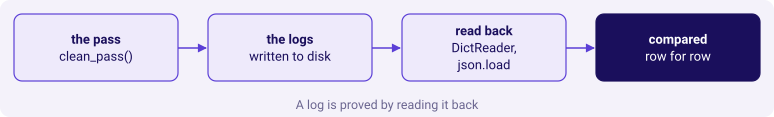

In [5]:
out = pathlib.Path(tempfile.mkdtemp())
with open(out / "set_aside_log.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=list(set_aside[0]))
    w.writeheader()
    w.writerows(set_aside)
with open(out / "decisions_log.json", "w", encoding="utf-8") as f:
    json.dump(decisions, f, indent=1)
with open(out / "set_aside_log.csv", newline="", encoding="utf-8") as f:
    back = list(csv.DictReader(f))       # read_orders() would overwrite the log's own line column
back_decisions = json.load(open(out / "decisions_log.json", encoding="utf-8"))
kit.flow(["the pass\nclean_pass()", "the logs\nwritten to disk", "read back\nDictReader, json.load",
          "compared\nrow for row"], lit=3, title="A log is proved by reading it back")
kit.check("the set-aside log reads back 15 rows", len(back) == len(set_aside) == 15)
kit.check("the decisions log reads back five decisions", len(back_decisions) == 5)
kit.check("the rupees in the file equal the rupees in the notebook",
          sum(convert(r["amount"])[0] or 0 for r in back if r["quarter"] == "Q1") == q1_aside)

**What happened.** The answer is b. The log went out as text and comes back as text, which is why
the rupee check converts it again. Chapter 1's rule, that everything read from a CSV stays text
until it is converted on purpose, holds for your own files too.

**Your turn.** In the empty cell, print the set-aside log as the analyst will read it, with
`print(open(out / "set_aside_log.csv").read())`. Pick one row and follow its `kept_line` to the
row that stayed.

## 4. If the rows reconcile, is the log right?

**The plausible wrong answer.** A colleague built the pass in the order that feels natural: remove
repeated ids first, keeping the first copy, then convert and reject what fails. The log looks
perfect.

In [6]:
seen, first_copy, col_aside = set(), [], []
for r in raw:
    if r["order_id"] in seen:
        col_aside.append(r)
        continue
    seen.add(r["order_id"])
    first_copy.append(r)
col_clean = [dict(r, amount=convert(r["amount"])[0]) for r in first_copy if convert(r["amount"])[0] is not None]
col_rejects = [r for r in first_copy if convert(r["amount"])[0] is None]
col_aside_q1 = sum(convert(r["amount"])[0] or 0 for r in col_aside if r["quarter"] == "Q1")
kit.stats([(f"{len(raw)} = {len(col_clean)} + {len(col_aside) + len(col_rejects)}", "rows reconcile", "in equals kept plus logged"),
           (kit.rupees(col_aside_q1), "Q1 set aside", "Anand's gap, to the lakh"),
           (f"Rs {Q(col_clean, 'Q1') / 1e7:.2f} crore", "Q1 clean", "as the note rounds it")],
          caption="The colleague's log, as it would be sent")

**Why it is wrong.** Rs 20,00,000 set aside looks like Anand's gap, and the rows tie, and Q1 rounds to
1.9. To the rupee, Q1 is Rs 1,790 short of the books: keeping the first copy kept one whose amount
could not be read, rejected it, and set aside its twin, the other copy of the same order, which
carried the value. A row reconciliation proves no row vanished; it cannot prove the right rows
stayed. The analyst ties to the rupee, finds an order on the books missing from a file called
reconciled, and questions every other line. Two checks catch it: the books against the clean Q1,
and a rejected order whose twin sits in the set-aside log.

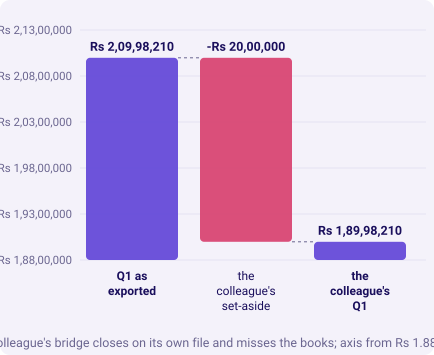

In [7]:
rejected_ids = {r["order_id"] for r in col_rejects}
orphaned = [r for r in col_aside if r["order_id"] in rejected_ids and convert(r["amount"])[0] is not None]
kit.check("the colleague's rows reconcile", len(raw) == len(col_clean) + len(col_aside) + len(col_rejects))
kit.check("the colleague's Q1 misses the books by Rs 1,790", BOOKS_Q1 - Q(col_clean, "Q1") == 1790)
kit.check("a rejected order has a twin with a value in the set-aside log", len(orphaned) == 1)
kit.bridge(("Q1 as exported", Q(raw, "Q1")), [("the colleague's set-aside rows", -col_aside_q1)],
           end_label="the colleague's Q1", lo=18800000,
           title="The colleague's bridge closes on its own file and misses the books; axis from Rs 1.88 crore")

**The fix, and what changed.** The pass's own order, as `clean_pass()` runs it: the identity rule
first, keeping the copy whose amount converts, then conversion. The Rs 1,790 order comes back; the
unreadable copy goes to the set-aside log with its twin named, so the rejects log is empty; and both
totals tie: rows 201 = 186 + 15, rupees to the books.

## 5. Why were 14 Q1 rows set aside, and how do we know nothing else went?

The auditor writes: "Your log says 14 Q1 rows were dropped. Why those 14, and how do I know nothing
else went with them?"

**Predict before you run.** Which evidence answers "nothing else went"? a) the count 14; b) every one
of the 14 has a kept twin, and Q1 rows and rupees both tie; c) the log is sorted; d) the file is smaller.

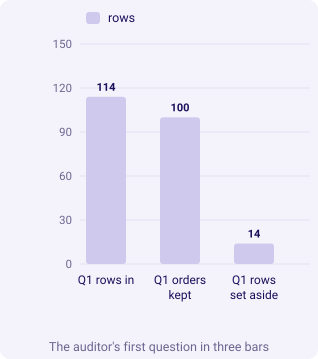

In [8]:
kept_ids = {r["order_id"] for r in clean}
q1_rows = [e for e in set_aside if e["quarter"] == "Q1"]
twins = sum(1 for e in q1_rows if e["order_id"] in kept_ids)
q1_in = sum(1 for r in raw if r["quarter"] == "Q1")
q1_kept = sum(1 for r in clean if r["quarter"] == "Q1")
kit.columns(["Q1 rows in", "Q1 orders kept", "Q1 rows set aside"], [("rows", [q1_in, q1_kept, len(q1_rows)])],
            title="The auditor's first question in three bars")
kit.check("14 Q1 rows set aside", len(q1_rows) == 14)
kit.check("every one has a kept twin", twins == 14)
kit.check("Q1 rows tie: in equals kept plus set aside", q1_in == q1_kept + len(q1_rows))

**What happened.** The answer is b. The log's word for these rows is "set aside with a reason", and
"dropped" misdescribes them: 14 Q1 rows share an id with a kept row, each has its twin named on its
line, and Q1 ties in rows (114 = 100 + 14) and in rupees (the bridge). The second case this
afternoon walks the auditor through it in pairs.

## 6. Can the clean file be rebuilt from the raw export and the log alone?

The strongest test of a log, and the second route here, is that a stranger can rebuild the clean file
from the raw export and the log alone, without the notebook's code.

In [9]:
gone = {int(r["line"]) for r in back} | {r["line"] for r in rejects}
replayed = [dict(r, amount=int(r["amount"])) for r in raw if r["line"] not in gone]
same = sorted((r["order_id"], r["amount"]) for r in replayed) == sorted((r["order_id"], r["amount"]) for r in clean)
kit.table(["route", "orders", "Q1", "Q2"],
          [("clean_pass()", len(clean), kit.rupees(Q(clean, "Q1")), kit.rupees(Q(clean, "Q2"))),
           ("raw export less the logged lines", len(replayed), kit.rupees(Q(replayed, "Q1")), kit.rupees(Q(replayed, "Q2")))])
kit.check("replaying the log reproduces the clean file exactly", same)

route,orders,Q1,Q2
clean_pass(),186,"Rs 1,90,00,000","Rs 1,87,00,000"
raw export less the logged lines,186,"Rs 1,90,00,000","Rs 1,87,00,000"


**When to switch.** The control totals are the quick test the analyst runs first; the replay is the
test for an auditor who trusts nothing, and it is the one to run before any log leaves the team.

Kavya Nair, the senior analyst on the team, checks every number before it leaves.

> **Kavya's review.** "A log is finished when a stranger can replay it: rows and rupees both tie,
> every line carries a reason, and every copy names its twin."

### In the interview: how do you walk an auditor through 14 rows set aside, and are you done when row counts reconcile?

**[D] An auditor asks why you dropped 14 rows; walk them through it.** "They were set aside, not
dropped, and each is in the log. Fourteen Q1 rows share an order id with another row; the identity
rule is the order id, because the ERP issues one per order. For each pair I kept the copy whose
fields validate. Each line of the log carries the source line, the key, the rule, the reason, the
value and the line of the row that stayed, and a decisions log carries each rule's rows and rupees.
Two corporate copies carry Rs 19,67,560 and the rest Rs 30,650. Q1 rows tie, 114 in and 100 kept,
the rupees bridge to your books exactly, and replaying the log on the raw export rebuilds my clean
file. A full diff I would add only for an external auditor who has to re-derive every row."

**[F] Your row counts reconcile. Are you done?** "No. Rows prove nothing vanished; rupees prove the
right rows stayed. A colleague's pass here tied in rows and was Rs 1,790 short."

### Depth: where else do control totals run, and why does a log carry its export's name?

A control total is a count or a sum computed at both ends of a transfer and compared: rows sent
against rows received, rupees exported against rupees loaded. Finance teams keep them per batch, so
a load that drops or doubles rows is caught before anyone reads a report. A log is also only
replayable against the export it was written for, so it carries the export's name, row count and
date, and a new export gets a new log. Week 2 keeps these totals in the warehouse.

## So can the analyst audit every decision tonight and rebuild the clean file from the log alone?

1. The analyst should receive the logs and control totals: 24 lines, about 12 minutes, tying rows
   and rupees and replayable, where the clean file read against the raw runs to 387 lines.
2. The identity rule moved the most rupees, all Rs 19,98,210; the other four decisions move no Q1
   rupees, and each still gets a line.
3. The logs on disk hold what the notebook holds: read back, they give 15 set-aside rows and 5
   decisions, with every amount back as text.
4. Rows that reconcile do not make the log right: the colleague's 201 = 185 + 16 ties the rows and
   misses the books by Rs 1,790.
5. Each of the 14 Q1 rows has a kept twin under the same order id, and Q1 ties in rows,
   114 = 100 + 14, and in rupees.
6. The raw export less the 15 logged lines rebuilds the clean file: the same 186 orders at the same
   amounts.

Yes. The analyst gets 24 lines of logs with two control totals, rows 201 = 186 + 15 and rupees on
the books, and the raw export less the 15 logged lines rebuilds the same 186 orders.

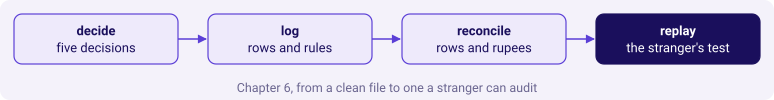

Next: the escalated case asks whether you can run the whole pass alone and send Anand a reconciliation his analyst can audit; Thursday asks whether the smaller Retail-Plus fall is real.


In [10]:
kit.flow(["decide\nfive decisions", "log\nrows and rules", "reconcile\nrows and rupees",
          "replay\nthe stranger's test"], lit=3, title="Chapter 6, from a clean file to one a stranger can audit")
kit.check_summary()
print("Next: the escalated case asks whether you can run the whole pass alone and send Anand a "
      "reconciliation his analyst can audit; Thursday asks whether the smaller Retail-Plus fall is real.")